In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score    
from sklearn.pipeline import Pipeline

In [12]:
df = pd.read_csv("placement.csv")
df.head()


,X,Y
0,-3.0,7.8
1,-2.9,7.1
2,-2.8,6.9
3,-2.7,6.3
4,-2.6,5.8


In [13]:
X = df[["X"]]
y = df[["Y"]]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
lr = LinearRegression()

In [16]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = lr.predict(X_test)

print("R-squared:", (r2_score(y_test, y_pred)*100))
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)

R-squared: 2.785946367234271
Intercept: [4.01562064]
Coefficients: [[0.49930178]]


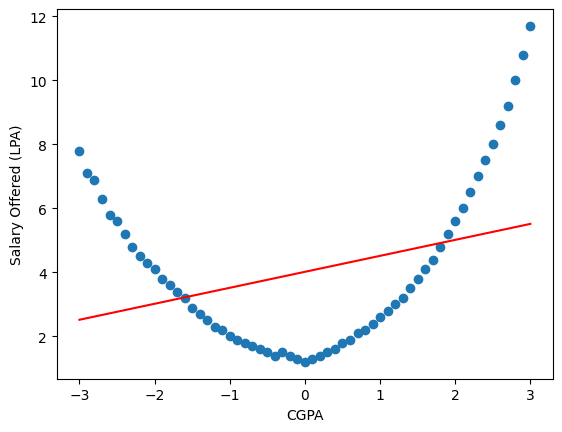

In [18]:
# drawing the scatter plot
plt.scatter(X, y)
# plot the prediction line 
plt.plot(X, lr.predict(X), color='red')
plt.xlabel("CGPA")
plt.ylabel("Salary Offered (LPA)")
plt.show()

Ploynomial Regression


R-squared: 99.18142508860292
Intercept: [1.3766496]
Coefficients: [[0.         0.46892053 0.88161408]]
type of coefficients <class 'numpy.ndarray'>
Length of Coefficients: 3


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


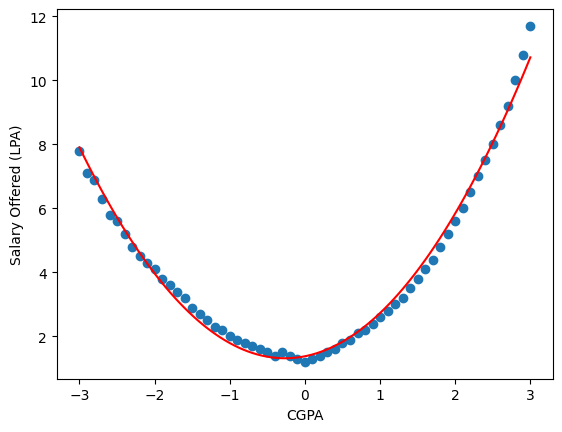

In [19]:
polynomialLr = PolynomialFeatures(degree=2)

X_train_transform = polynomialLr.fit_transform(X_train)
X_test_transform = polynomialLr.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transform, y_train)

y_pred = lr.predict(X_test_transform)

print("R-squared:", (r2_score(y_test, y_pred)*100))
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)
coeff = lr.coef_[0]
print(f"type of coefficients",type(coeff))
print("Length of Coefficients:", len(coeff))

# Scatter plot
plt.scatter(X, y)

# Smooth curve
X_grid = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
X_grid_poly = polynomialLr.transform(X_grid)

plt.plot(X_grid, lr.predict(X_grid_poly), color='red')

plt.xlabel("CGPA")
plt.ylabel("Salary Offered (LPA)")
plt.show()


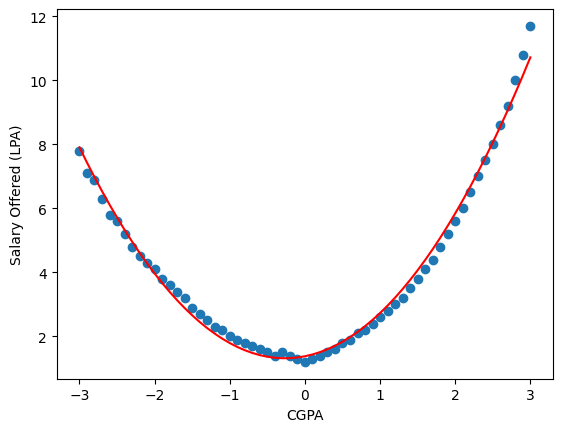

In [20]:
plt.scatter(X, y)

plt.plot(X,
         lr.predict(polynomialLr.transform(X)),
         color='red')

plt.xlabel("CGPA")
plt.ylabel("Salary Offered (LPA)")
plt.show()